In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import scipy.optimize
import seaborn as sns


from matplotlib.ticker import (MultipleLocator, FormatStrFormatter, AutoMinorLocator,NullFormatter,LogLocator)
majorFormatter = FormatStrFormatter('%d')

from mpl_toolkits.axes_grid1.inset_locator import (inset_axes, InsetPosition,
                                                  mark_inset)
plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=10)

plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

In [4]:
# EVOLUTION WITHOUT DISENTANGLING

L_list = [16, 32, 64, 128, 256, 512]
p_list = [0.1, 0.12, 0.14, 0.16, 0.18, 0.2, 0.22, 0.24, 0.26, 0.28, 0.3, 0.32, 0.34, 0.36, 0.38]#, 0.4, 0.42, 0.44, 0.46]
cases = 100

ent_entropy_evolution = []
nullity_evolution = []

profile_steady = []
halfchain_steady = np.zeros((len(L_list), len(p_list)))
nullity_steady = np.zeros((len(L_list), len(p_list)))


for ii, L in enumerate(L_list):
    ent_entropy_evolution.append([])
    nullity_evolution.append([])

    profile_steady.append([])
    for jj, p in enumerate(p_list):

        count = 0
        for case in range(cases):
            try:
                filename = f'/space/ge24yov/gaussian_nonstabilizerness//results_mipt_p'+str("%.2f"%p)+f'_L{L}_case{case}.pkl'    
                with open(filename, 'rb') as f:
                    data = pickle.load(f)
                count += 1
            except:
                continue

                
            if count == 1:
                ent_entropy_evolution[ii].append(data['ent_entropies_evolution'])
                nullity_evolution[ii].append(data['nullity_evolution'])
                #square_ev = data['ent_entropies_evolution']**2
                profile_steady[ii].append(data['profile_steady'])
                nullity_steady[ii,jj] += data['nullity_steady']
            else:
                ent_entropy_evolution[ii][jj] += data['ent_entropies_evolution']
                nullity_evolution[ii][jj] += data['nullity_evolution']
                profile_steady[ii][jj] += data['profile_steady']
                nullity_steady[ii,jj] += data['nullity_steady']

        ent_entropy_evolution[ii][jj] /= count
        nullity_evolution[ii][jj] /= count

        profile_steady[ii][jj] /= count
        halfchain_steady[ii,jj] = profile_steady[ii][jj][L//2]
        nullity_steady[ii,jj] /= count
        
        print(L, p, count)

data = {}


data['L_list'] = L_list
data['p_list'] = p_list

data['ent_entropies_evolution'] = ent_entropy_evolution
data['nullity_evolution'] = nullity_evolution   

data['profiles_steady'] = profile_steady
data['halfchain_steady'] = halfchain_steady
data['nullity_steady'] = nullity_steady

filename = f'/space/ge24yov/gaussian_nonstabilizerness//results.pkl'
    
with open(filename, 'wb') as f:
    pickle.dump(data, f, pickle.HIGHEST_PROTOCOL)  

16 0.1 100
16 0.12 100
16 0.14 100
16 0.16 100
16 0.18 100
16 0.2 100
16 0.22 100
16 0.24 100
16 0.26 100
16 0.28 100
16 0.3 100
16 0.32 100
16 0.34 100
16 0.36 100
16 0.38 100
32 0.1 100
32 0.12 100
32 0.14 100
32 0.16 100
32 0.18 100
32 0.2 100
32 0.22 100
32 0.24 100
32 0.26 100
32 0.28 100
32 0.3 100
32 0.32 100
32 0.34 100
32 0.36 100
32 0.38 100
64 0.1 100
64 0.12 100
64 0.14 100
64 0.16 100
64 0.18 100
64 0.2 100
64 0.22 100
64 0.24 100
64 0.26 100
64 0.28 100
64 0.3 100
64 0.32 100
64 0.34 100
64 0.36 100
64 0.38 100
128 0.1 100
128 0.12 100
128 0.14 100
128 0.16 100
128 0.18 100
128 0.2 100
128 0.22 100
128 0.24 100
128 0.26 100
128 0.28 100
128 0.3 100
128 0.32 100
128 0.34 100
128 0.36 100
128 0.38 100
256 0.1 100
256 0.12 100
256 0.14 100
256 0.16 100
256 0.18 100
256 0.2 100
256 0.22 100
256 0.24 100
256 0.26 100
256 0.28 100
256 0.3 100
256 0.32 100
256 0.34 100
256 0.36 100
256 0.38 100
512 0.1 100
512 0.12 100
512 0.14 100
512 0.16 100
512 0.18 100
512 0.2 100
512 0.22 

In [5]:
filename = f'/space/ge24yov/gaussian_nonstabilizerness//results.pkl'

with open(filename, 'rb') as f:
    data = pickle.load(f)

L_list = data['L_list']
p_list = data['p_list']

ent_entropy_evolution = data['ent_entropies_evolution']
nullity_evolution = data['nullity_evolution']

profile_steady = data['profiles_steady']
halfchain_steady = data['halfchain_steady']
nullity_steady = data['nullity_steady']

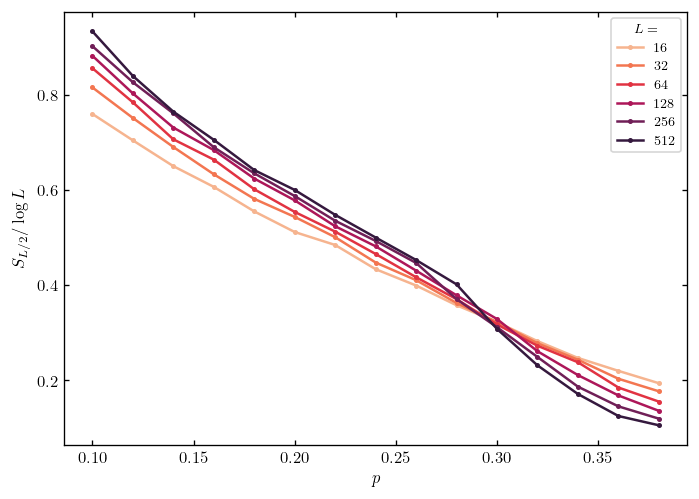

In [6]:
color_list = sns.color_palette('rocket_r', n_colors = len(L_list))


fig, ax = plt.subplots(figsize=(3.35*2, 3.35*(0.7)*2), dpi=120)
ax.tick_params(which='both', bottom=True, top=True, left=True, right=True)
ax.tick_params(axis='both', which='major', direction='in', length = 3, labelsize=10)
ax.tick_params(axis='both', which='minor', direction='in')
for ii, L in enumerate(L_list):
    ax.plot(p_list, halfchain_steady[ii]/np.log(L), '-o', label = rf'{L}', color = color_list[ii], markersize = 2)
#ax.plot(np.linspace(10, 140, 1000), np.linspace(10, 140, 1000)**0.75/4, color = 'grey', linestyle='dashed')
ax.legend(loc=0, prop={'size': 8}, ncol =1, title = '$L=$', title_fontsize=8)
ax.set_xlabel('$p$', fontsize=10)  # Set the xlabel size
ax.set_ylabel(r'$S_{L/2}/\log L$', fontsize=10)  # Set the xlabel size

#plt.xscale('log')
#plt.yscale('log')

plt.show()

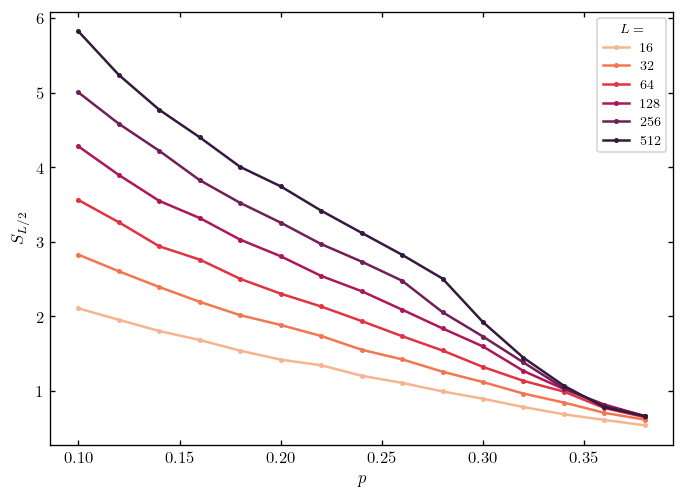

In [7]:
color_list = sns.color_palette('rocket_r', n_colors = len(L_list))


fig, ax = plt.subplots(figsize=(3.35*2, 3.35*(0.7)*2), dpi=120)
ax.tick_params(which='both', bottom=True, top=True, left=True, right=True)
ax.tick_params(axis='both', which='major', direction='in', length = 3, labelsize=10)
ax.tick_params(axis='both', which='minor', direction='in')
for ii, L in enumerate(L_list):
    ax.plot(p_list, halfchain_steady[ii], '-o', label = rf'{L}', color = color_list[ii], markersize = 2)
#ax.plot(np.linspace(10, 140, 1000), np.linspace(10, 140, 1000)**0.75/4, color = 'grey', linestyle='dashed')
ax.legend(loc=0, prop={'size': 8}, ncol =1, title = '$L=$', title_fontsize=8)
ax.set_xlabel('$p$', fontsize=10)  # Set the xlabel size
ax.set_ylabel(r'$S_{L/2}$', fontsize=10)  # Set the xlabel size

#plt.xscale('log')
#plt.yscale('log')

plt.show()

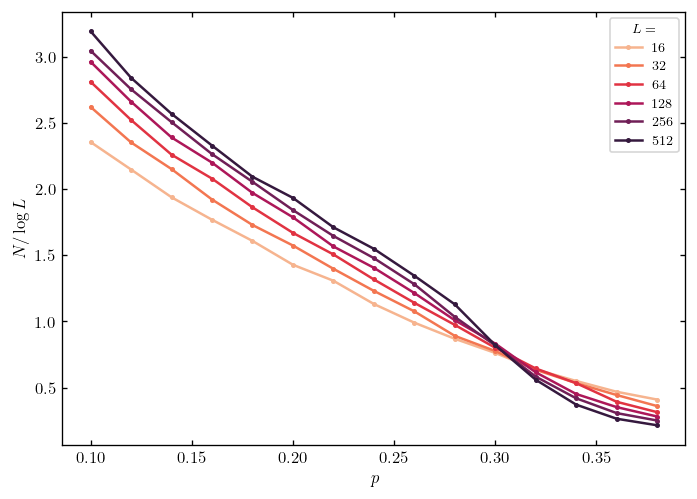

In [14]:
color_list = sns.color_palette('rocket_r', n_colors = len(L_list))


fig, ax = plt.subplots(figsize=(3.35*2, 3.35*(0.7)*2), dpi=120)
ax.tick_params(which='both', bottom=True, top=True, left=True, right=True)
ax.tick_params(axis='both', which='major', direction='in', length = 3, labelsize=10)
ax.tick_params(axis='both', which='minor', direction='in')
for ii, L in enumerate(L_list):
    ax.plot(p_list, nullity_steady[ii]/np.log(L), '-o', label = rf'{L}', color = color_list[ii], markersize = 2)
#ax.plot(np.linspace(10, 140, 1000), np.linspace(10, 140, 1000)**0.75/4, color = 'grey', linestyle='dashed')
ax.legend(loc=0, prop={'size': 8}, ncol =1, title = '$L=$', title_fontsize=8)
ax.set_xlabel('$p$', fontsize=10)  # Set the xlabel size
ax.set_ylabel(r'$N/\log L$', fontsize=10)  # Set the xlabel size

#plt.xscale('log')
#plt.yscale('log')

plt.show()

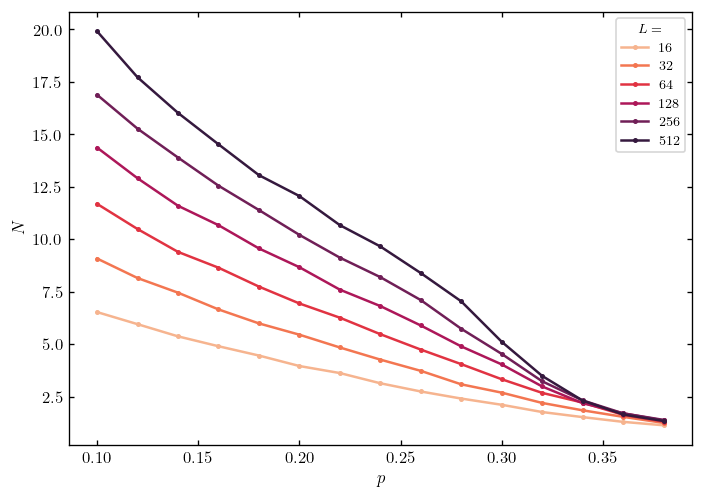

In [9]:
color_list = sns.color_palette('rocket_r', n_colors = len(L_list))


fig, ax = plt.subplots(figsize=(3.35*2, 3.35*(0.7)*2), dpi=120)
ax.tick_params(which='both', bottom=True, top=True, left=True, right=True)
ax.tick_params(axis='both', which='major', direction='in', length = 3, labelsize=10)
ax.tick_params(axis='both', which='minor', direction='in')
for ii, L in enumerate(L_list):
    ax.plot(p_list, nullity_steady[ii], '-o', label = rf'{L}', color = color_list[ii], markersize = 2)
#ax.plot(np.linspace(10, 140, 1000), np.linspace(10, 140, 1000)**0.75/4, color = 'grey', linestyle='dashed')
ax.legend(loc=0, prop={'size': 8}, ncol =1, title = '$L=$', title_fontsize=8)
ax.set_xlabel('$p$', fontsize=10)  # Set the xlabel size
ax.set_ylabel(r'$N$', fontsize=10)  # Set the xlabel size

#plt.xscale('log')
#plt.yscale('log')

plt.show()

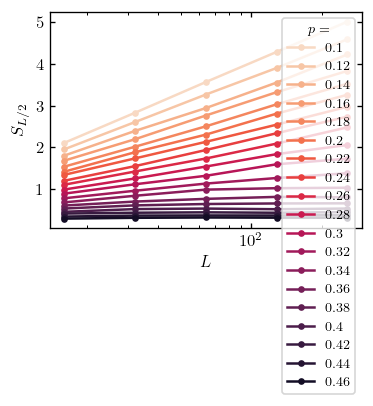

In [8]:

color_list = sns.color_palette('rocket_r', n_colors = len(p_list))


fig, ax = plt.subplots(figsize=(3.35, 3.35*(0.7)), dpi=120)
ax.tick_params(which='both', bottom=True, top=True, left=True, right=True)
ax.tick_params(axis='both', which='major', direction='in', length = 3, labelsize=10)
ax.tick_params(axis='both', which='minor', direction='in')
count = 0
for jj,p in enumerate(p_list):
    ax.plot(L_list, halfchain_steady[:,jj], '-o', label = rf'{p}', color = color_list[count], markersize =3)
    count += 1
#ax.plot(np.linspace(1, 10**3, 10**3), np.linspace(1, 10**3, 10**3)**0.44/1.5, color = 'grey', linestyle='dashed')
ax.legend(loc=0, prop={'size': 8}, ncol =1, title = '$p=$', title_fontsize=8)
ax.set(xlabel = '$L$',ylabel = r'$S_{L/2}$')
plt.xscale('log')
#plt.yscale('log')
plt.show()

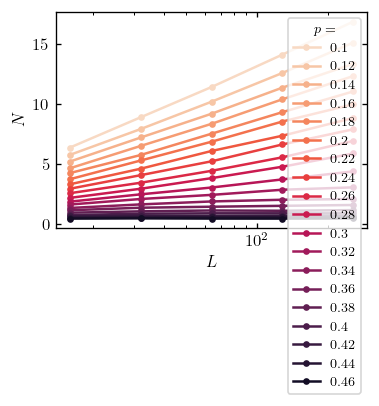

In [14]:

color_list = sns.color_palette('rocket_r', n_colors = len(p_list))


fig, ax = plt.subplots(figsize=(3.35, 3.35*(0.7)), dpi=120)
ax.tick_params(which='both', bottom=True, top=True, left=True, right=True)
ax.tick_params(axis='both', which='major', direction='in', length = 3, labelsize=10)
ax.tick_params(axis='both', which='minor', direction='in')
count = 0
for jj,p in enumerate(p_list):
    ax.plot(L_list, nullity_steady[:,jj], '-o', label = rf'{p}', color = color_list[count], markersize =3)
    count += 1
#ax.plot(np.linspace(1, 10**3, 10**3), np.linspace(1, 10**3, 10**3)**0.44/1.5, color = 'grey', linestyle='dashed')
ax.legend(loc=0, prop={'size': 8}, ncol =1, title = '$p=$', title_fontsize=8)
ax.set(xlabel = '$L$',ylabel = r'$N$')
plt.xscale('log')
#plt.yscale('log')
plt.show()

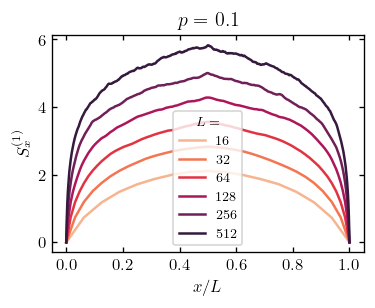

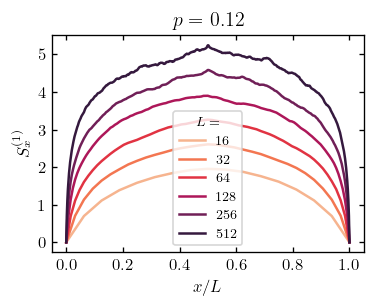

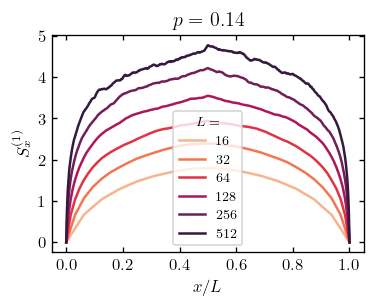

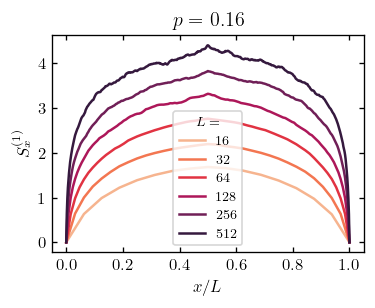

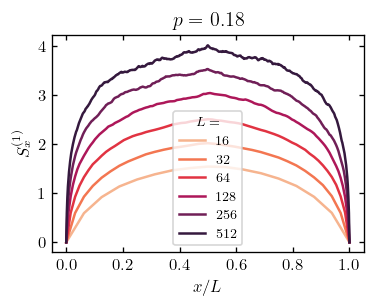

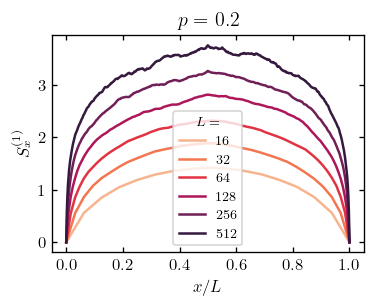

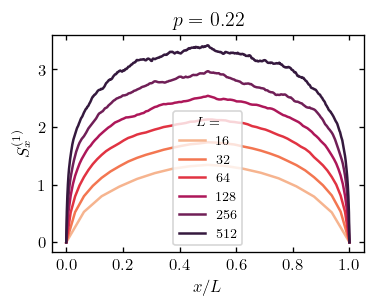

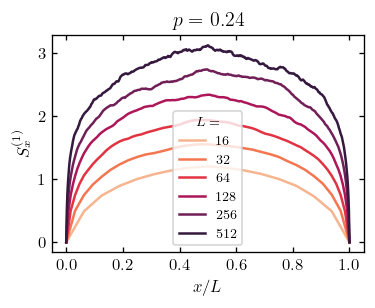

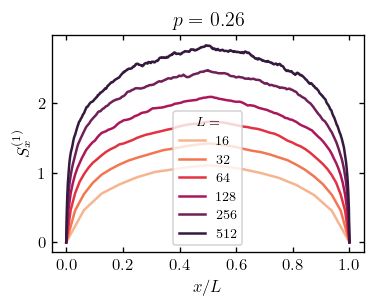

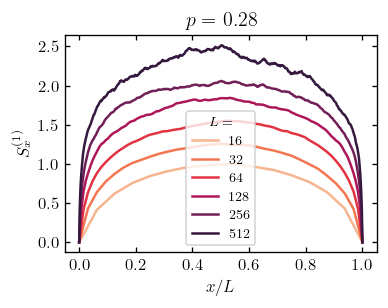

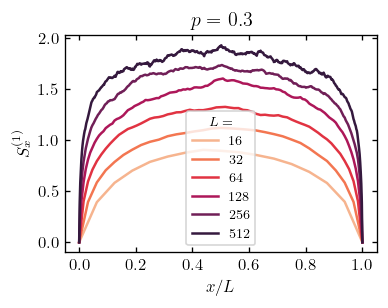

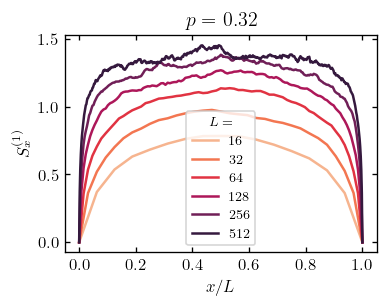

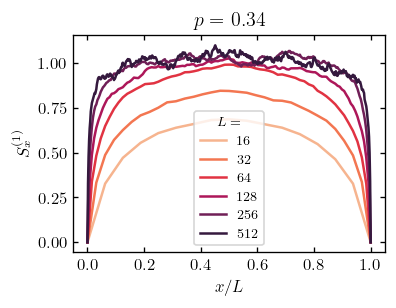

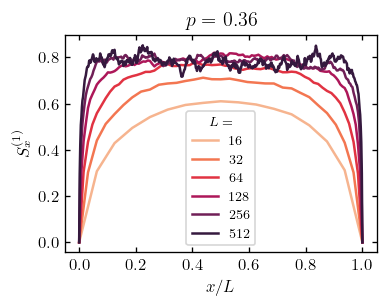

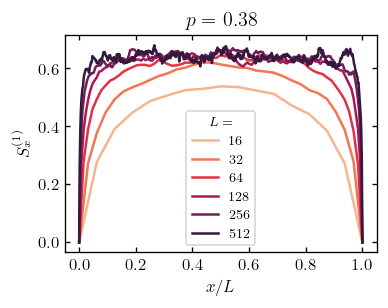

In [10]:

for jj, p in enumerate(p_list):

    color_list = sns.color_palette('rocket_r', n_colors = len(L_list))


    
    fig, ax = plt.subplots(figsize=(3.35, 3.35*(0.7)), dpi=120)
    ax.tick_params(which='both', bottom=True, top=True, left=True, right=True)
    ax.tick_params(axis='both', which='major', direction='in', length = 3, labelsize=10)
    ax.tick_params(axis='both', which='minor', direction='in')
    for ii, L in enumerate(L_list):
        ax.plot(np.arange(L+1)/L, profile_steady[ii][jj], '-', label = rf'{L}', color = color_list[ii], markersize=1)

    #ax.plot(np.linspace(1, 2*10**4, 10**3), np.linspace(1, 2*10**4, 10**3)**0.5, color = 'grey', linestyle='dashed')
    ax.legend(loc=0, prop={'size': 8}, ncol =1, title = '$L=$', title_fontsize=8)
    ax.set(xlabel = '$x/L$',ylabel = r'$S_x^{(1)}$')
    plt.title(rf'$p=$ {p}')
    plt.show()

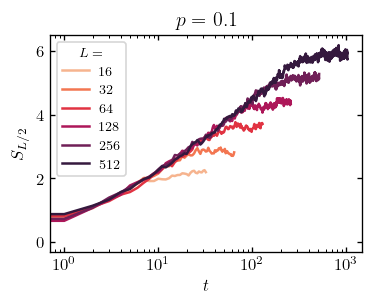

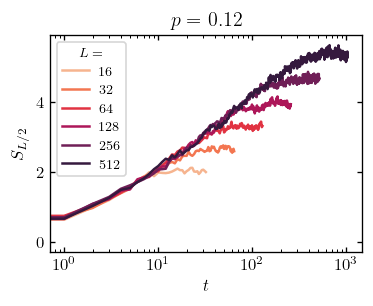

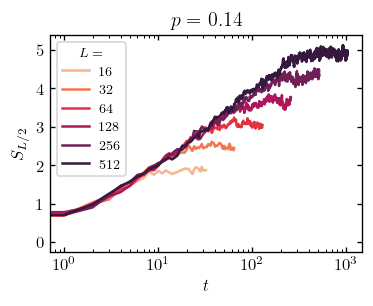

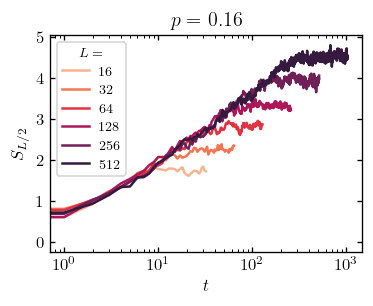

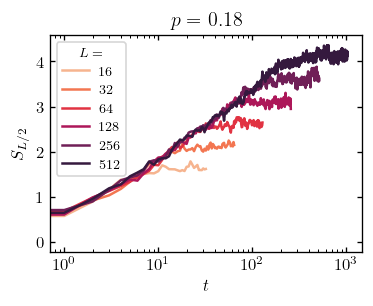

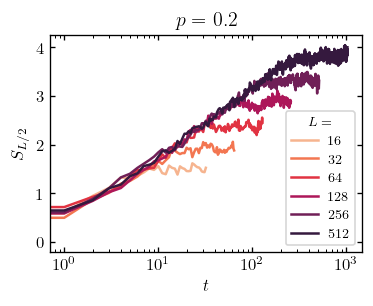

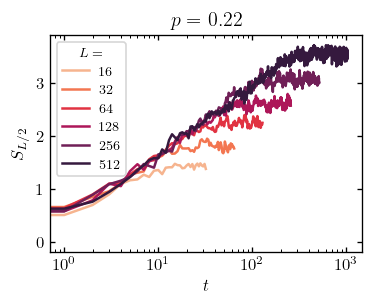

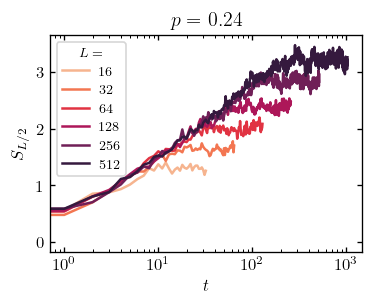

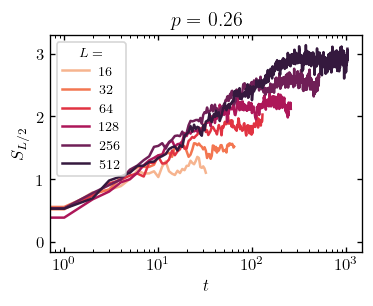

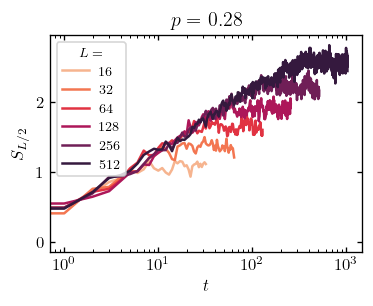

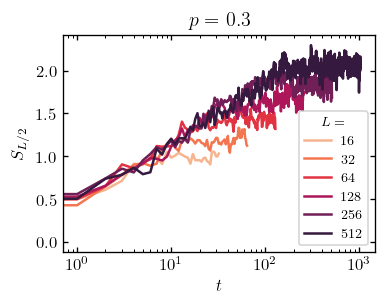

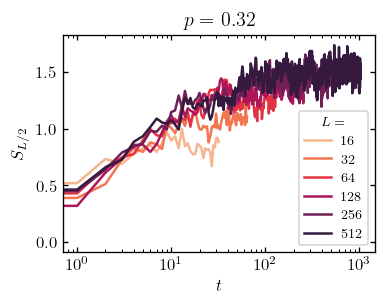

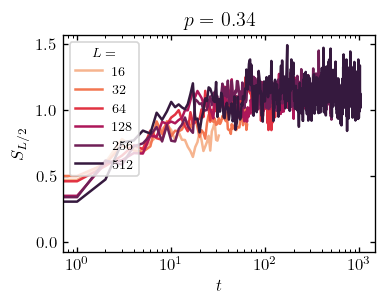

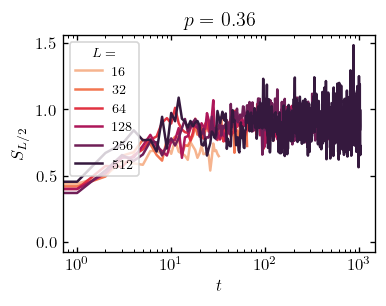

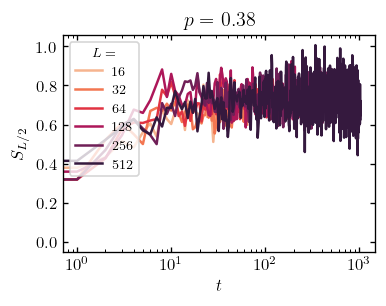

In [11]:

for jj, p in enumerate(p_list):
    color_list = sns.color_palette('rocket_r', n_colors = len(L_list))


    fig, ax = plt.subplots(figsize=(3.35, 3.35*(0.7)), dpi=120)
    ax.tick_params(which='both', bottom=True, top=True, left=True, right=True)
    ax.tick_params(axis='both', which='major', direction='in', length = 3, labelsize=10)
    ax.tick_params(axis='both', which='minor', direction='in')
    for ii, L in enumerate(L_list):
        ax.plot(np.arange(2*L+1), ent_entropy_evolution[ii][jj][:2*L+1], '-', label = rf'{L}', color = color_list[ii], markersize = 2)
    #ax.plot(np.linspace(10, 140, 1000), np.linspace(10, 140, 1000)**0.75/4, color = 'grey', linestyle='dashed')
    ax.legend(loc=0, prop={'size': 8}, ncol =1, title = '$L=$', title_fontsize=8)
    ax.set_xlabel('$t$', fontsize=10)  # Set the xlabel size
    ax.set_ylabel(r'$S_{L/2}$', fontsize=10)  # Set the xlabel size
    ax.set_title(rf'$p=$ {p}')

    plt.xscale('log')
    #plt.yscale('log')

    plt.show()

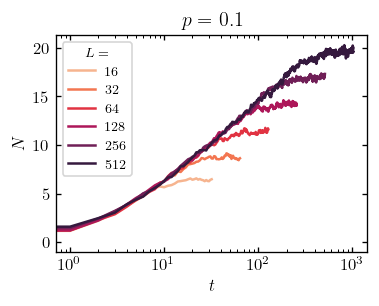

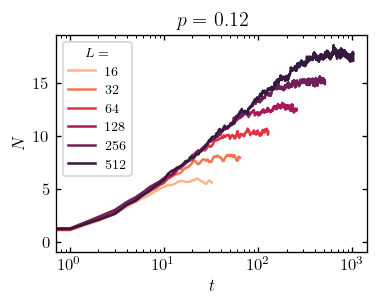

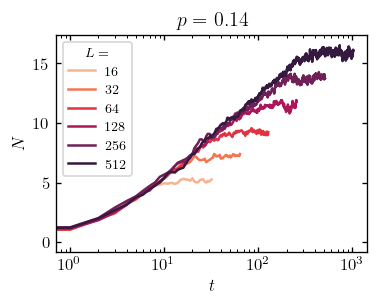

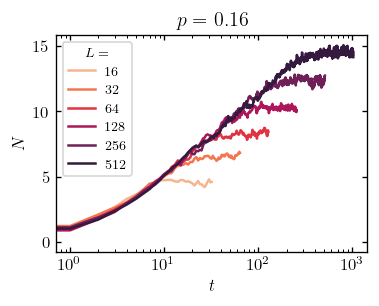

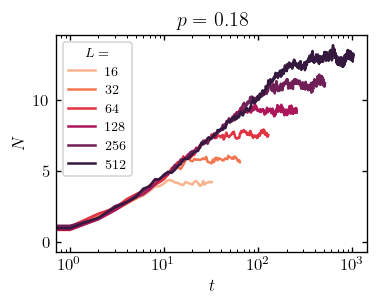

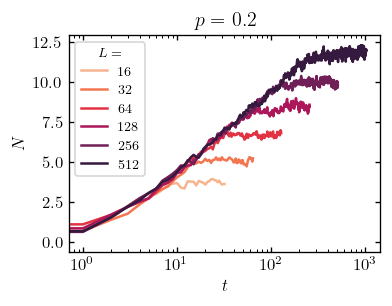

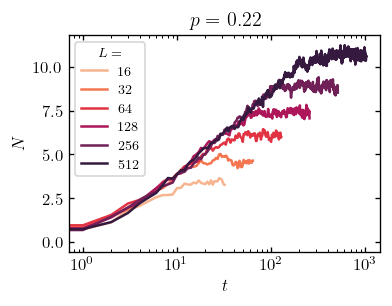

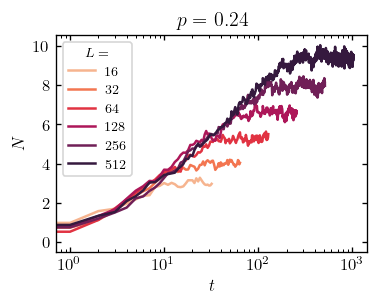

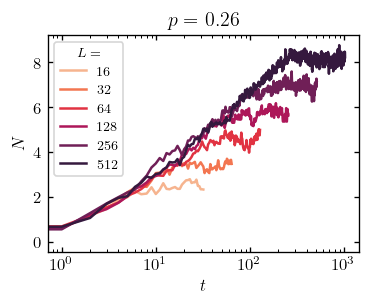

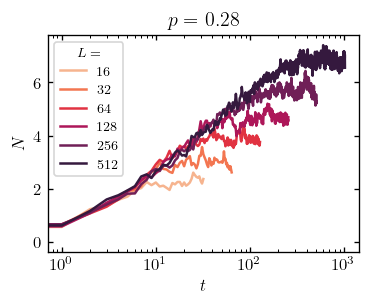

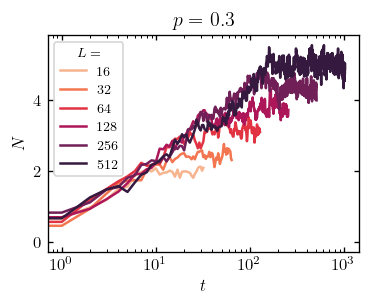

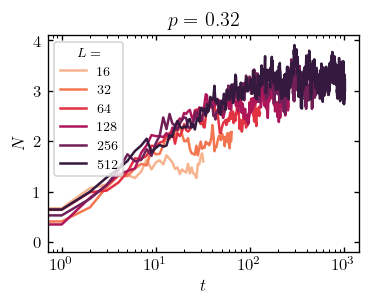

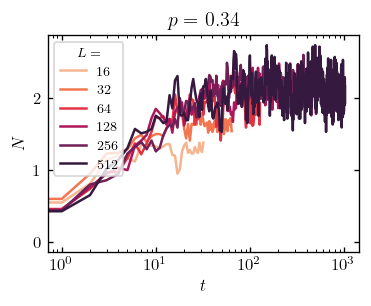

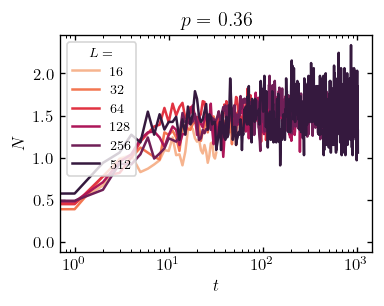

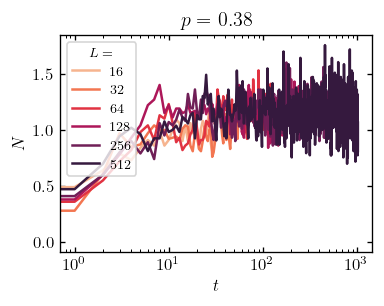

In [12]:

for jj, p in enumerate(p_list):
    color_list = sns.color_palette('rocket_r', n_colors = len(L_list))


    fig, ax = plt.subplots(figsize=(3.35, 3.35*(0.7)), dpi=120)
    ax.tick_params(which='both', bottom=True, top=True, left=True, right=True)
    ax.tick_params(axis='both', which='major', direction='in', length = 3, labelsize=10)
    ax.tick_params(axis='both', which='minor', direction='in')
    for ii, L in enumerate(L_list):
        ax.plot(np.arange(2*L+1), nullity_evolution[ii][jj][:2*L+1], '-', label = rf'{L}', color = color_list[ii], markersize = 2)
    #ax.plot(np.linspace(10, 140, 1000), np.linspace(10, 140, 1000)**0.75/4, color = 'grey', linestyle='dashed')
    ax.legend(loc=0, prop={'size': 8}, ncol =1, title = '$L=$', title_fontsize=8)
    ax.set_xlabel('$t$', fontsize=10)  # Set the xlabel size
    ax.set_ylabel(r'$N$', fontsize=10)  # Set the xlabel size
    ax.set_title(rf'$p=$ {p}')
    plt.xscale('log')
    #plt.yscale('log')

    plt.show()

In [12]:
# EVOLUTION WITHOUT DISENTANGLING

L_list = [16, 32, 64, 128, 256]
p_list = [0.1]
cases = 100

ent_entropy_evolution_r = []
nullity_evolution_r = []

profile_steady_r = []
halfchain_steady_r = np.zeros((len(L_list), len(p_list)))
nullity_steady_r = np.zeros((len(L_list), len(p_list)))


for ii, L in enumerate(L_list):
    ent_entropy_evolution_r.append([])
    nullity_evolution_r.append([])

    profile_steady_r.append([])
    for jj, p in enumerate(p_list):

        count = 0
        for case in range(cases):
            filename = f'/space/ge24yov/gaussian_nonstabilizerness//results_mipt_p'+str("%.2f"%p)+f'_L{L}_init_state_random_case{case}.pkl'    
            with open(filename, 'rb') as f:
                data = pickle.load(f)
            count += 1

                
            if count == 1:
                ent_entropy_evolution_r[ii].append(data['ent_entropies_evolution'])
                nullity_evolution_r[ii].append(data['nullity_evolution'])
                #square_ev = data['ent_entropies_evolution']**2
                profile_steady_r[ii].append(data['profile_steady'])
                nullity_steady_r[ii,jj] += data['nullity_steady']
            else:
                ent_entropy_evolution_r[ii][jj] += data['ent_entropies_evolution']
                nullity_evolution_r[ii][jj] += data['nullity_evolution']
                profile_steady_r[ii][jj] += data['profile_steady']
                nullity_steady_r[ii,jj] += data['nullity_steady']

        ent_entropy_evolution_r[ii][jj] /= count
        nullity_evolution_r[ii][jj] /= count

        profile_steady_r[ii][jj] /= count
        halfchain_steady_r[ii,jj] = profile_steady_r[ii][jj][L//2]
        nullity_steady_r[ii,jj] /= count
        
        print(L, p, count)


16 0.1 100
32 0.1 100
64 0.1 100
128 0.1 100
256 0.1 100


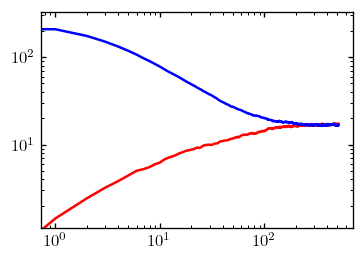

In [13]:
color_list = sns.color_palette('rocket_r', n_colors = len(L_list))


fig, ax = plt.subplots(figsize=(3.35, 3.35*(0.7)), dpi=120)
ax.tick_params(which='both', bottom=True, top=True, left=True, right=True)
ax.tick_params(axis='both', which='major', direction='in', length = 3, labelsize=10)
ax.tick_params(axis='both', which='minor', direction='in')
ax.plot(np.arange(2*L+1), nullity_evolution[-1][0][:2*L+1], '-', label = rf'{L}', color = 'red', markersize = 2)
ax.plot(np.arange(2*L+1), nullity_evolution_r[-1][0][:2*L+1], '-', label = rf'{L}', color = 'blue', markersize = 2)
plt.yscale('log')
plt.xscale('log')
plt.show()


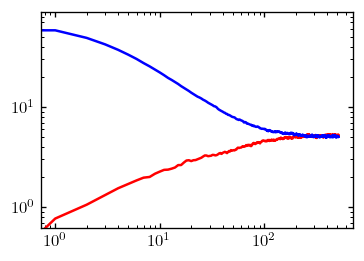

In [84]:
color_list = sns.color_palette('rocket_r', n_colors = len(L_list))


fig, ax = plt.subplots(figsize=(3.35, 3.35*(0.7)), dpi=120)
ax.tick_params(which='both', bottom=True, top=True, left=True, right=True)
ax.tick_params(axis='both', which='major', direction='in', length = 3, labelsize=10)
ax.tick_params(axis='both', which='minor', direction='in')
ax.plot(np.arange(2*L+1), ent_entropy_evolution[-1][0][:2*L+1], '-', label = rf'{L}', color = 'red', markersize = 2)
ax.plot(np.arange(2*L+1), ent_entropy_evolution_r[-1][0][:2*L+1], '-', label = rf'{L}', color = 'blue', markersize = 2)
plt.yscale('log')
plt.xscale('log')
plt.show()


In [72]:
# EVOLUTION WITHOUT DISENTANGLING

L_list = [16, 32, 64, 128, 256]
p_list = [0]
cases = 100

ent_entropy_evolution = []
nullity_evolution = []

profile_steady = []
halfchain_steady = np.zeros((len(L_list), len(p_list)))
nullity_steady = np.zeros((len(L_list), len(p_list)))


for ii, L in enumerate(L_list):
    ent_entropy_evolution.append([])
    nullity_evolution.append([])

    profile_steady.append([])
    for jj, p in enumerate(p_list):

        count = 0
        for case in range(cases):
            try:
                filename = f'/space/ge24yov/gaussian_nonstabilizerness//results_mipt_p'+str("%.2f"%p)+f'_L{L}_case{case}.pkl'    
                with open(filename, 'rb') as f:
                    data = pickle.load(f)
                count += 1
            except:
                continue

                
            if count == 1:
                ent_entropy_evolution[ii].append(data['ent_entropies_evolution'])
                nullity_evolution[ii].append(data['nullity_evolution'])
                #square_ev = data['ent_entropies_evolution']**2
                profile_steady[ii].append(data['profile_steady'])
                nullity_steady[ii,jj] += data['nullity_steady']
            else:
                ent_entropy_evolution[ii][jj] += data['ent_entropies_evolution']
                nullity_evolution[ii][jj] += data['nullity_evolution']
                profile_steady[ii][jj] += data['profile_steady']
                nullity_steady[ii,jj] += data['nullity_steady']

        ent_entropy_evolution[ii][jj] /= count
        nullity_evolution[ii][jj] /= count

        profile_steady[ii][jj] /= count
        halfchain_steady[ii,jj] = profile_steady[ii][jj][L//2]
        nullity_steady[ii,jj] /= count
        
        print(L, p, count)

data = {}


data['L_list'] = L_list
data['p_list'] = p_list

data['ent_entropies_evolution'] = ent_entropy_evolution
data['nullity_evolution'] = nullity_evolution   

data['profiles_steady'] = profile_steady
data['halfchain_steady'] = halfchain_steady
data['nullity_steady'] = nullity_steady

filename = f'/space/ge24yov/gaussian_nonstabilizerness//results.pkl'
    
with open(filename, 'wb') as f:
    pickle.dump(data, f, pickle.HIGHEST_PROTOCOL)  

16 0 100
32 0 100
64 0 100
128 0 100
256 0 100


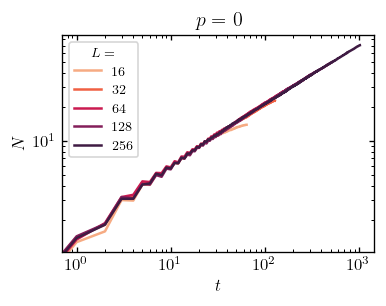

In [76]:

for jj, p in enumerate(p_list):
    color_list = sns.color_palette('rocket_r', n_colors = len(L_list))


    fig, ax = plt.subplots(figsize=(3.35, 3.35*(0.7)), dpi=120)
    ax.tick_params(which='both', bottom=True, top=True, left=True, right=True)
    ax.tick_params(axis='both', which='major', direction='in', length = 3, labelsize=10)
    ax.tick_params(axis='both', which='minor', direction='in')
    for ii, L in enumerate(L_list):
        ax.plot(np.arange(4*L+1), nullity_evolution[ii][jj], '-', label = rf'{L}', color = color_list[ii], markersize = 2)
    #ax.plot(np.linspace(10, 140, 1000), np.linspace(10, 140, 1000)**0.75/4, color = 'grey', linestyle='dashed')
    ax.legend(loc=0, prop={'size': 8}, ncol =1, title = '$L=$', title_fontsize=8)
    ax.set_xlabel('$t$', fontsize=10)  # Set the xlabel size
    ax.set_ylabel(r'$N$', fontsize=10)  # Set the xlabel size
    ax.set_title(rf'$p=$ {p}')
    plt.xscale('log')
    plt.yscale('log')

    plt.show()